# Frouth Stability analysis from a video

In [39]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv
import matplotlib.animation as animation

# Priliminary test

In [40]:
# reading the video
cap = cv.VideoCapture('rl4_pb17-4.mp4')

# getting the frame rate
fps = cap.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count}")



video fps: 29.703158414733778
video frame count: 938


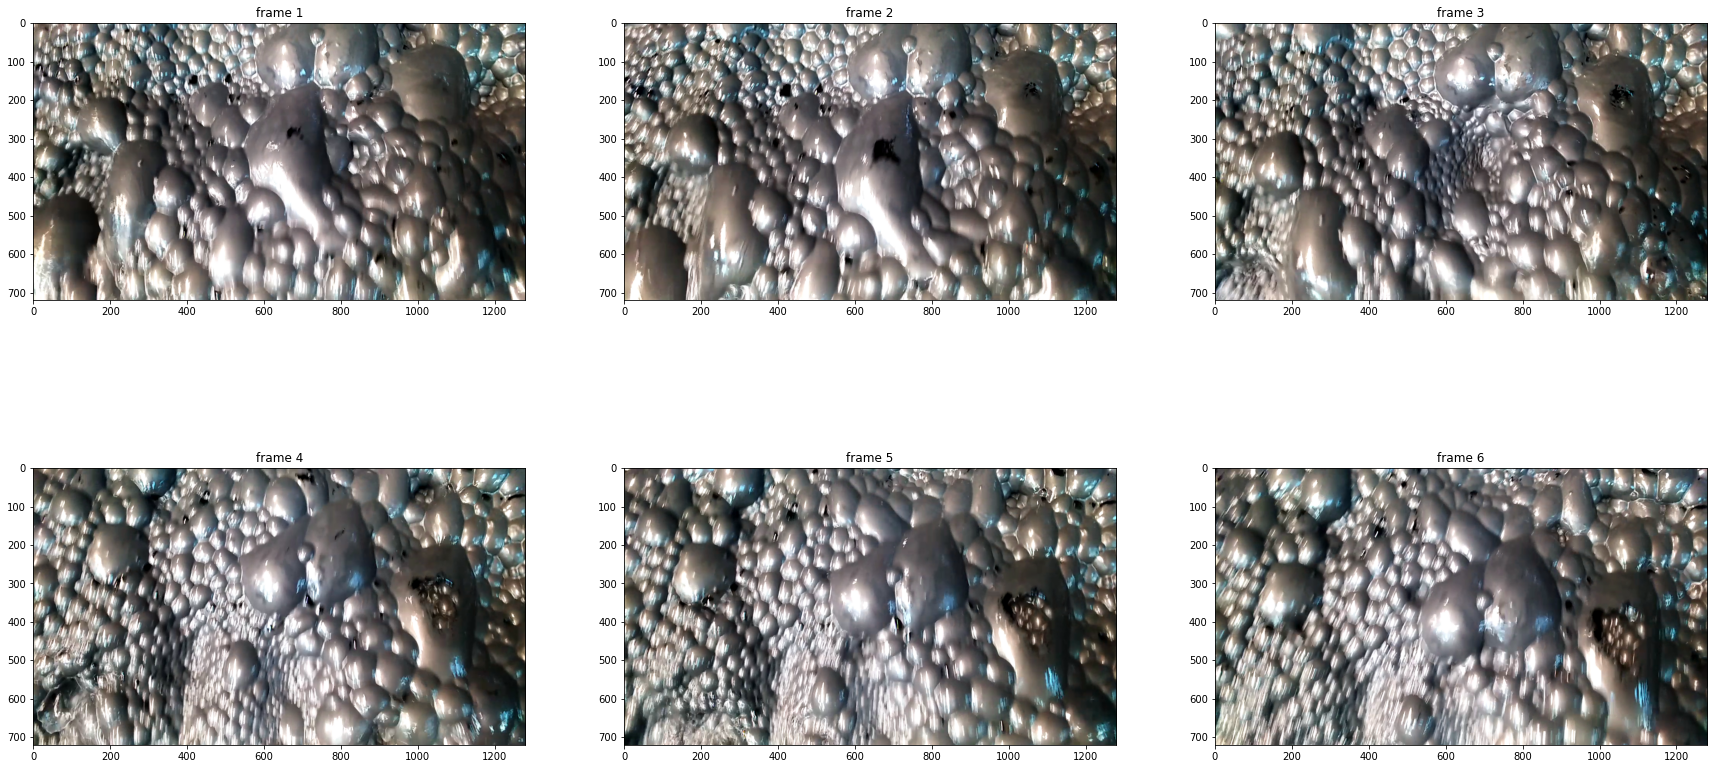

In [41]:
# getting frames from the second 7 to 7.5
cap.set(cv.CAP_PROP_POS_MSEC, 7500)
ret, frame = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 7600)
ret, frame2 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 7700)
ret, frame3 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8200)
ret, frame4 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8300)
ret, frame5 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8400)
ret, frame6 = cap.read()
# ploting the frames in a 2x2 grid
fig, ax = plt.subplots(2, 3, figsize=(30, 15))
ax[0, 0].imshow(frame)
ax[0, 0].set_title('frame 1')
ax[0, 1].imshow(frame2)
ax[0, 1].set_title('frame 2')
ax[0, 2].imshow(frame3)
ax[0, 2].set_title('frame 3')
ax[1, 0].imshow(frame4)
ax[1, 0].set_title('frame 4')
ax[1, 1].imshow(frame5)
ax[1, 1].set_title('frame 5')
ax[1, 2].imshow(frame6)
ax[1, 2].set_title('frame 6')

plt.show()


In [42]:
# converting the frames to grayscale
gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
#normalizing the frames using the min-max normalization
gray = cv.normalize(gray, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
gray2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)
gray2 = cv.normalize(gray2, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
gray3 = cv.cvtColor(frame3, cv.COLOR_BGR2GRAY)
gray3 = cv.normalize(gray3, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
gray4 = cv.cvtColor(frame4, cv.COLOR_BGR2GRAY)
gray4 = cv.normalize(gray4, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
gray5 = cv.cvtColor(frame5, cv.COLOR_BGR2GRAY)
gray5 = cv.normalize(gray5, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
gray6 = cv.cvtColor(frame6, cv.COLOR_BGR2GRAY)
gray6 = cv.normalize(gray6, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)


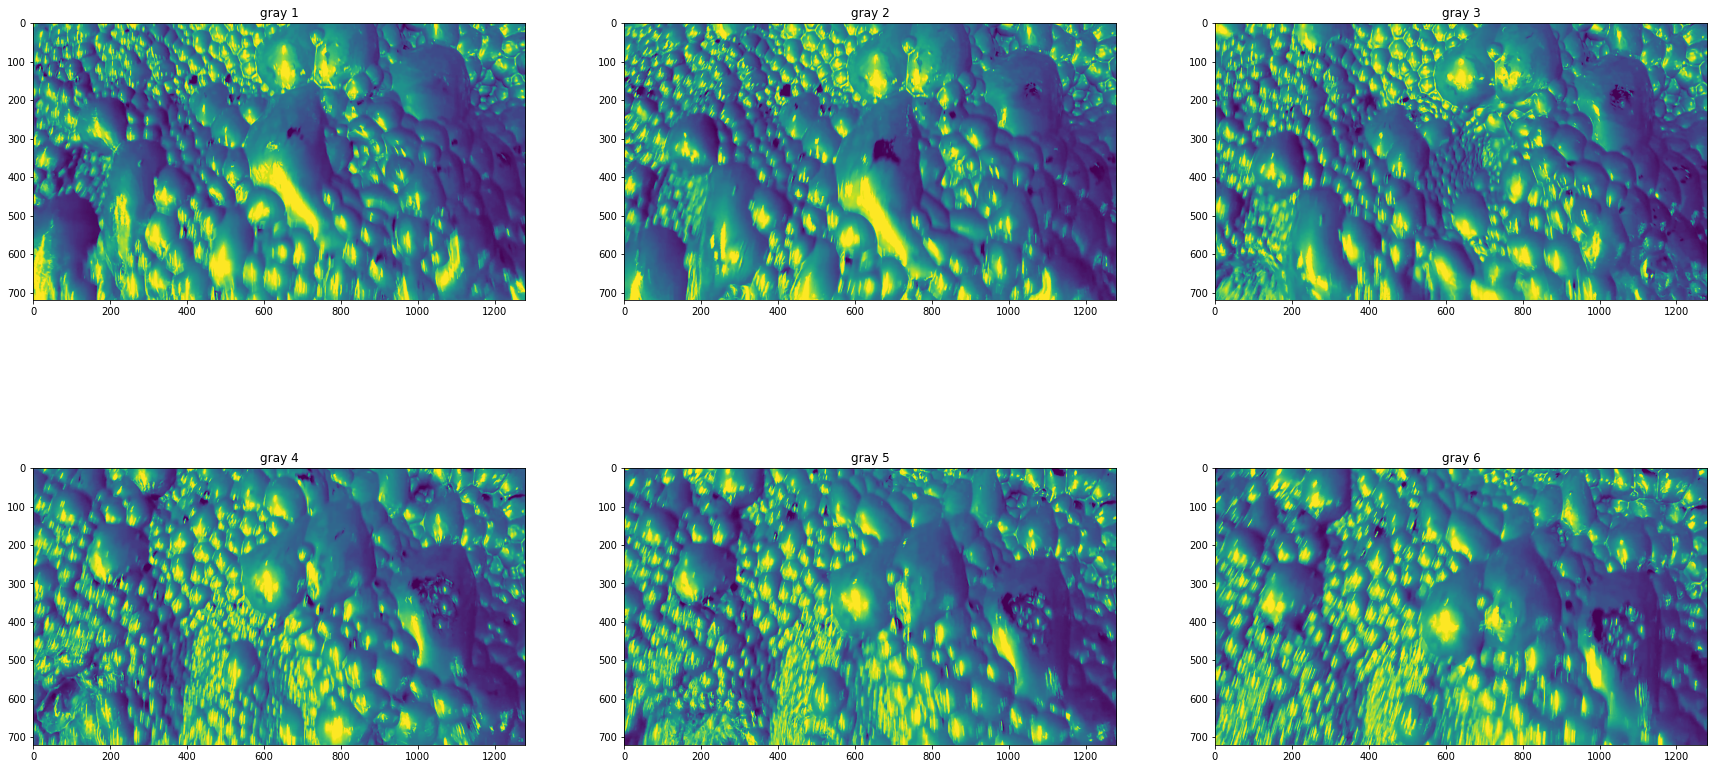

In [43]:
# ploting the frames in a 2x2 grid
fig, ax = plt.subplots(2, 3, figsize=(30, 15))
ax[0, 0].imshow(gray)
ax[0, 0].set_title('gray 1')
ax[0, 1].imshow(gray2)
ax[0, 1].set_title('gray 2')
ax[0, 2].imshow(gray3)
ax[0, 2].set_title('gray 3')
ax[1, 0].imshow(gray4)
ax[1, 0].set_title('gray 4')
ax[1, 1].imshow(gray5)
ax[1, 1].set_title('gray 5')
ax[1, 2].imshow(gray6)
ax[1, 2].set_title('gray 6')

plt.show()

## Average intensity between frame 1 and 2 

In [44]:
# Calculating the average of the grayscale frames
avg = (gray + gray2)/2

# claculating the avrage intensity of the average frame
avg_intensity = np.mean(avg)

avg_intensity

64.288984375

# Average intensity between frame 2 and 3

In [45]:
avg2 = (gray2 + gray3)/2
avg_intensity2 = np.mean(avg2)

avg_intensity2

66.01447808159722

# Average intensity between frame 2 and 4

In [46]:
avg3 = (gray2 + gray4)/2
avg_intensity3 = np.mean(avg3)

avg_intensity3

66.15469292534722

In [47]:
def applied_method(cap, frames_to_take):
    # getting the frame rate
    fps = cap.get(cv.CAP_PROP_FPS)
    # getting the frame count
    frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    
    frames = []
    gray_frames = []
    for i in range(0, frame_count, frames_to_take):
        ls = []
        ls2 = []
        for j in range(i,i+frames_to_take):
            ret, frame = cap.read()
            if ret == False:
                break
            else:
                # normalizing the frame
                gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
                gray = cv.normalize(gray, None, 0, 255, cv.NORM_MINMAX, cv.CV_8UC3)
                ls2.append(gray)
                ls.append(frame)
        if len(ls) == frames_to_take:
            gray_frames.append(ls2)
            frames.append(ls)

    # avg of each row in gray_frames
    avg_ls = []
    for row in gray_frames:
        avg_image = row[0]
        for i in range(len(row)):
            if i == 0:
                pass
            else:
                alpha = 1.0/(i + 1)
                beta = 1.0 - alpha
                avg_image = cv.addWeighted(avg_image, alpha, row[i], beta, 0.0)
        avg_ls.append(avg_image)



    # calculate the average intensity of the average frames
    avg_intensity_frames = []
    
    for i in range(len(avg_ls)):
        avg_intensity_frames.append(np.mean(avg_ls[i]))


    return avg_intensity_frames, frames

In [48]:
def plot_results(avg_intensity_frames):
    # ploting the average intensity of the average frames
    if len(avg_intensity_frames) > 100:
        for i in range(0, len(avg_intensity_frames), 100):
            plt.figure(figsize=(30, 10))
            plt.xticks(np.arange(0, len(avg_intensity_frames[i:i+100]), 1))
            plt.plot(avg_intensity_frames[i:i+100])
            plt.show()
    else:
        plt.figure(figsize=(20, 10))
        plt.xticks(np.arange(0, len(avg_intensity_frames), 1))
        plt.plot(avg_intensity_frames)
        plt.show()

In [49]:
def plot_diff_frames(frames,index,index2):
    # plot 2x5 subplots 
    fig, axs = plt.subplots(2, len(frames[index]), figsize=(20, 10))
    for i in range(len(frames[index])):
        axs[0, i].imshow(frames[index][i])
        axs[1, i].imshow(frames[index2][i])
        axs[0, i].set_title('frame ' + str(i))
        axs[1, i].set_title('frame ' + str(i))
    plt.show()

# Results for the first video

### The results are presented in plots, each plot represents the fluctuation of the average intensity, x-axis is the frames and y-axis is the average intensity.


In [50]:
# reading the video
cap = cv.VideoCapture('rl4_pb17-4.mp4')

frames_to_take = input("Enter the number of frames to take: ")
frames_to_take = int(frames_to_take)

# getting the frame rate
fps = cap.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count} ,frames tooked into consideration: {frames_to_take} , values = {frame_count/frames_to_take}")

# applying the method to the video
avg_intensity_frames, frames = applied_method(cap, frames_to_take)



video fps: 29.703158414733778
video frame count: 938 ,frames tooked into consideration: 5 , values = 187.6


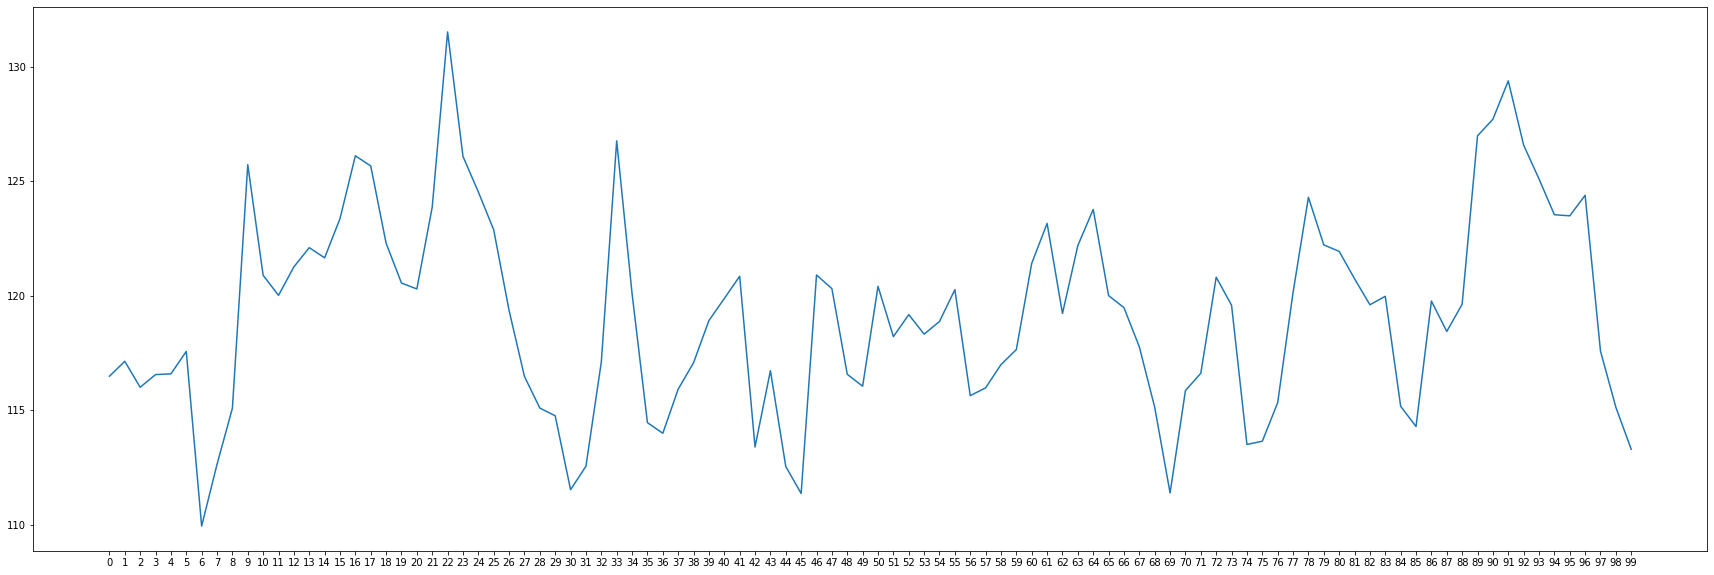

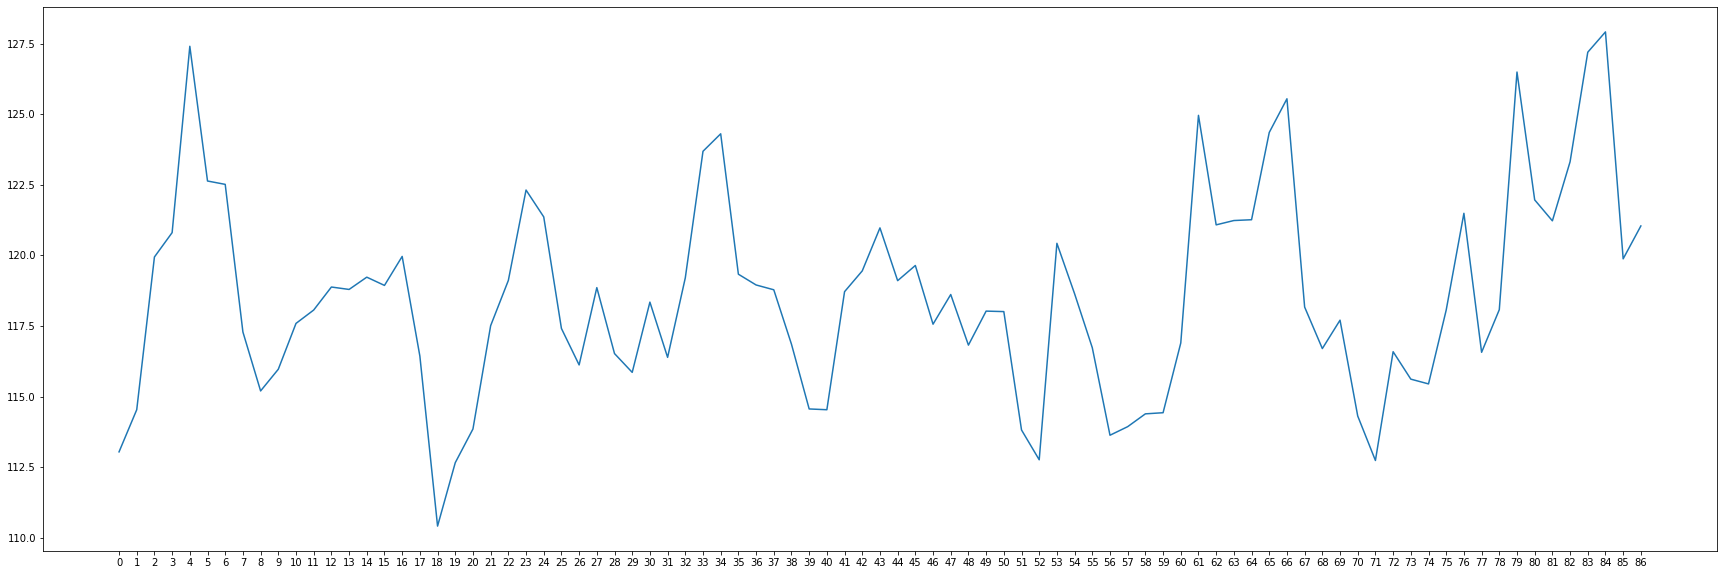

In [51]:
# ploting the average intensity of the average frames
plot_results(avg_intensity_frames)

### Understanding the results

We compare the frames where there is asignificant diffrence in values, if there is a big diffrence we can conclude that there is some forme of instability, whether is due to vilocity or actually bubbles collapse.

index of the biggest difference: 8 , 9


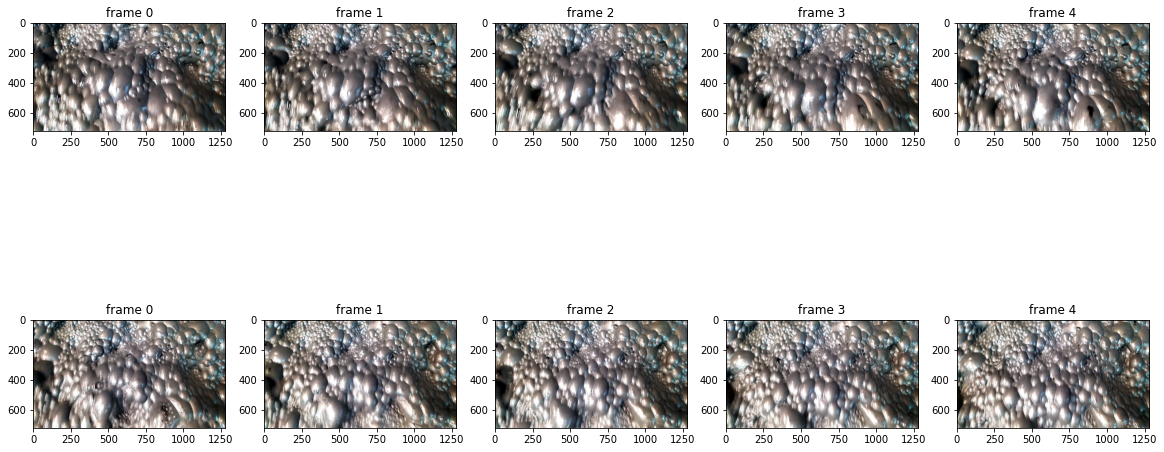

In [52]:
# get the index of the biggest difference between the frames
def get_index_of_biggest_difference(avg_intensity_frames):
    # getting the index of the biggest difference between the frames
    index_of_biggest_difference = []
    for i in range(len(avg_intensity_frames)-1):
        index_of_biggest_difference.append(abs(avg_intensity_frames[i] - avg_intensity_frames[i+1]))

    index_of_biggest_difference = np.argmax(index_of_biggest_difference)
    return index_of_biggest_difference

index_of_biggest_difference = get_index_of_biggest_difference(avg_intensity_frames)

print(f"index of the biggest difference: {index_of_biggest_difference} , {index_of_biggest_difference + 1}")

plot_diff_frames(frames,index_of_biggest_difference, index_of_biggest_difference + 1)


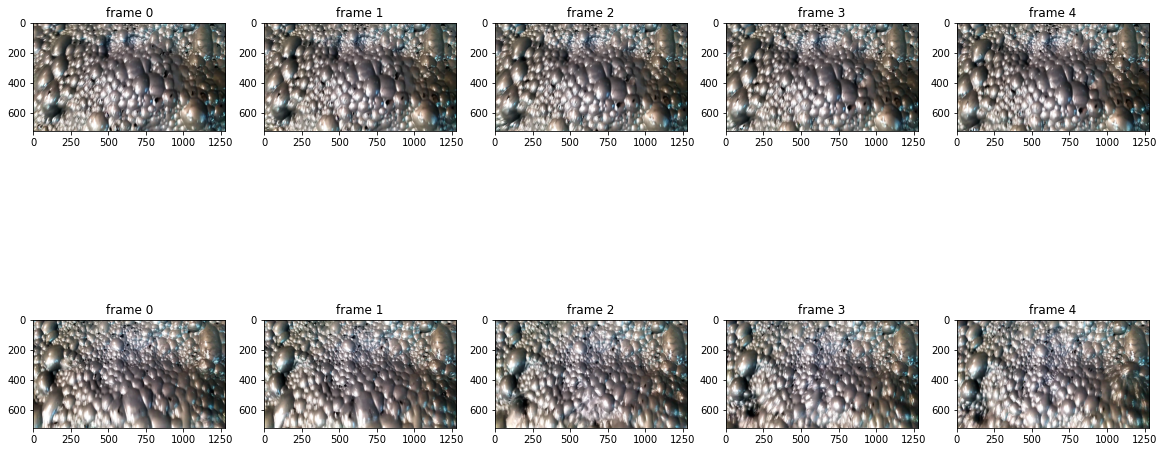

In [53]:
plot_diff_frames(frames,30, 33)

# Results for the second video

### The results are presented in plots, each plot represents the fluctuation of the average intensity, x-axis is the frames and y-axis is the average intensity.


In [54]:
cap2 = cv.VideoCapture('rl4_pb8-7.mp4')

# getting the frame rate
fps2 = cap2.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

frames_to_take = input("Enter the number of frames to take: ")
frames_to_take = int(frames_to_take)
# getting the frame count
frame_count2 = int(cap2.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count2} ,frames tooked into consideration: {frames_to_take} , values = {frame_count2/frames_to_take}")

# applying the method to the video
avg_intensity_frames2, frames2 = applied_method(cap2, frames_to_take)


video fps: 29.703158414733778
video frame count: 898 ,frames tooked into consideration: 5 , values = 179.6


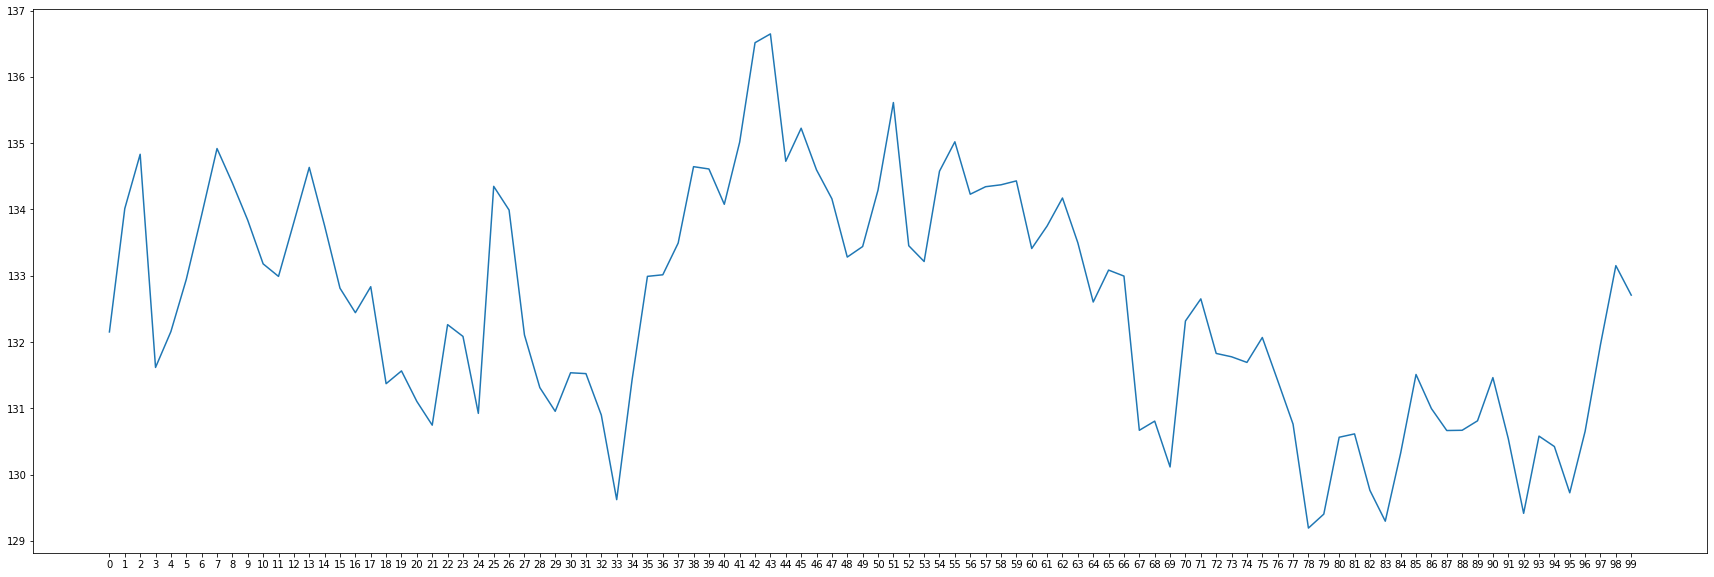

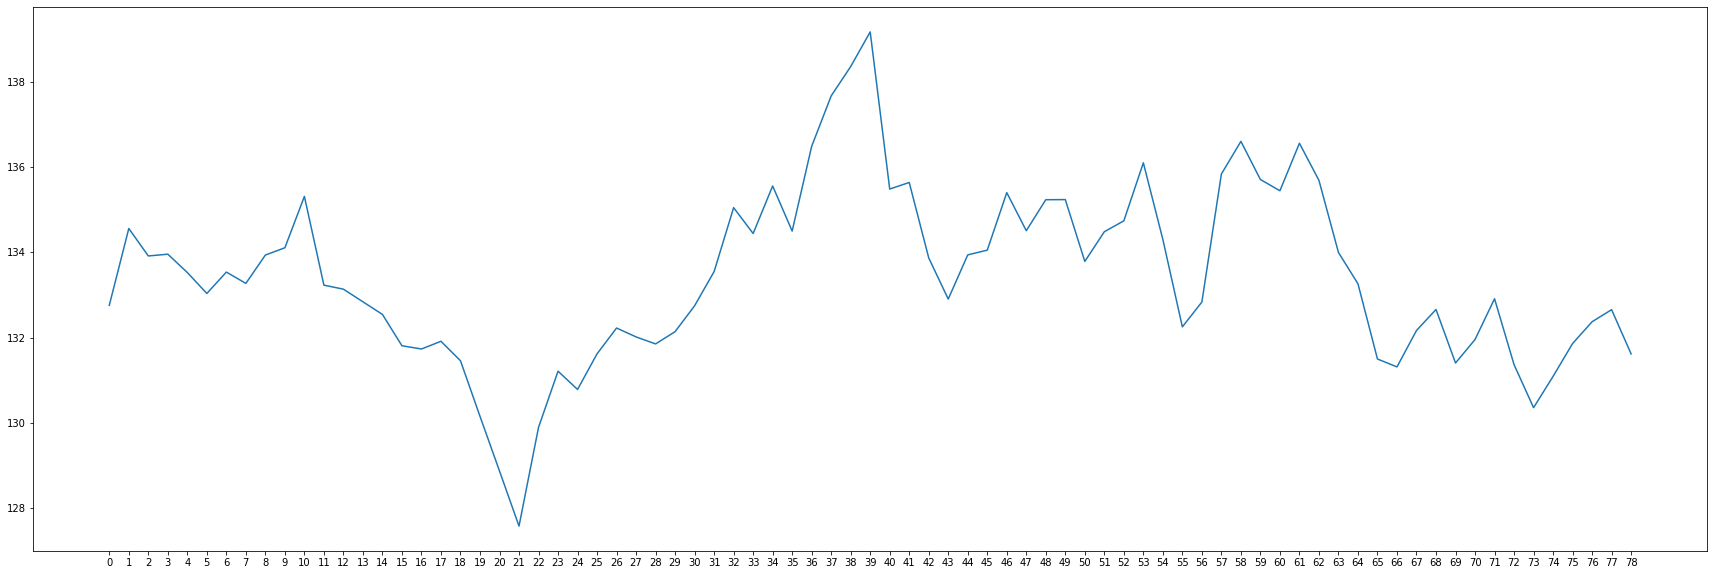

In [55]:
# ploting the average intensity of the average frames
plot_results(avg_intensity_frames2)

index of the biggest difference: 139 , 140


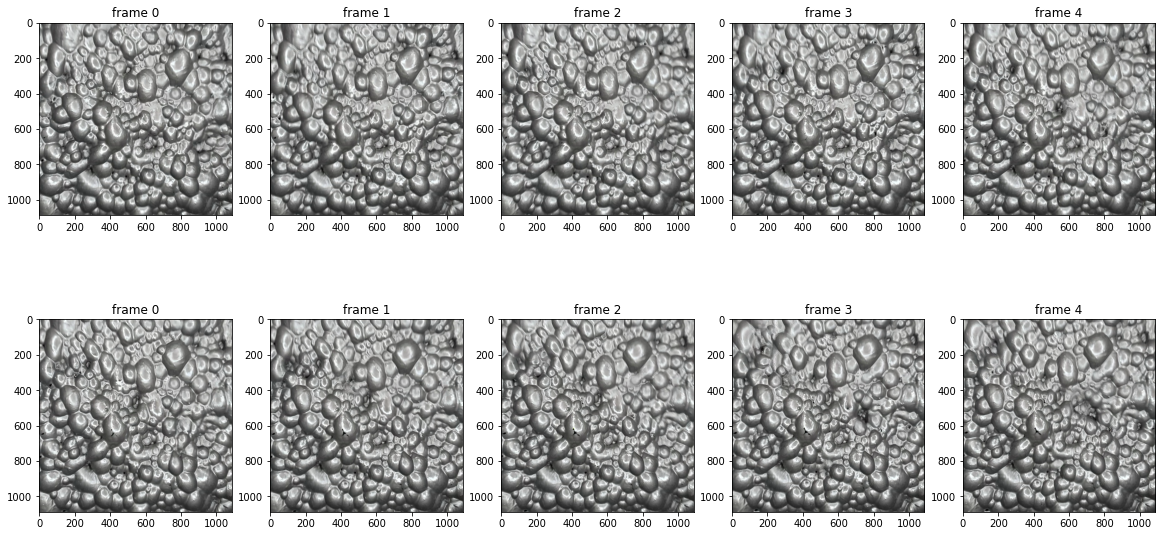

In [56]:
index_of_biggest_difference2 = get_index_of_biggest_difference(avg_intensity_frames2)

print(f"index of the biggest difference: {index_of_biggest_difference2} , {index_of_biggest_difference2 + 1}")

plot_diff_frames(frames2,index_of_biggest_difference2, index_of_biggest_difference2 + 1)


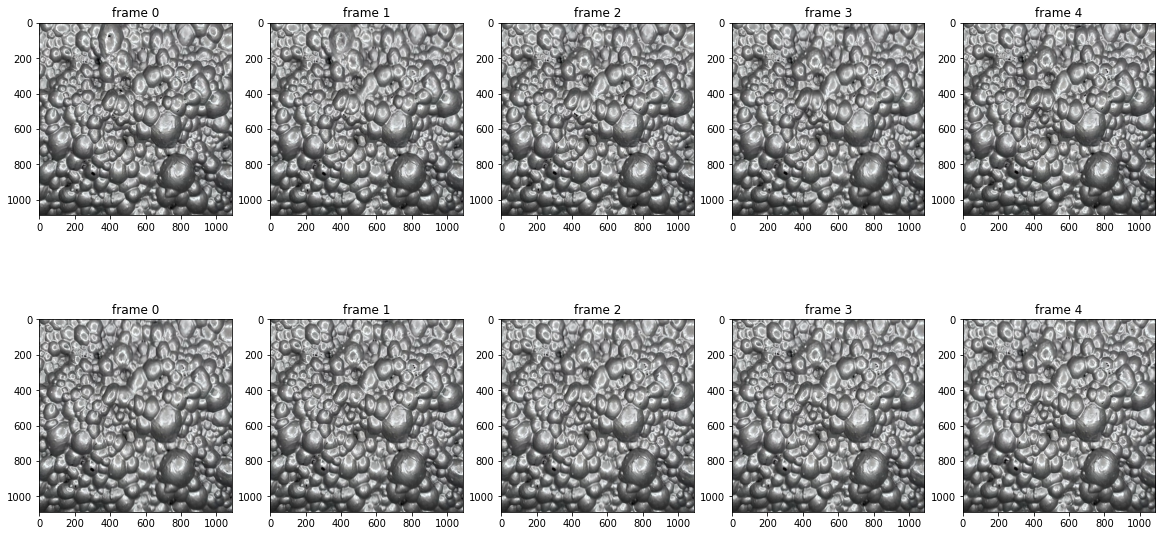

In [57]:
plot_diff_frames(frames2,24, 25)

# We can tell that there is a lot of noise in our results due to the velocity effect. so we need to reduce the noise.

# Alignments

### preliminary test

In [58]:
from vidstab import VidStab

stabilizer = VidStab()
stabilizer.stabilize(input_path='rl4_pb17-4.mp4', output_path='stable_video.avi')

video fps: 29.0
video frame count: 938 ,frames tooked into consideration: 5 , values = 187.6


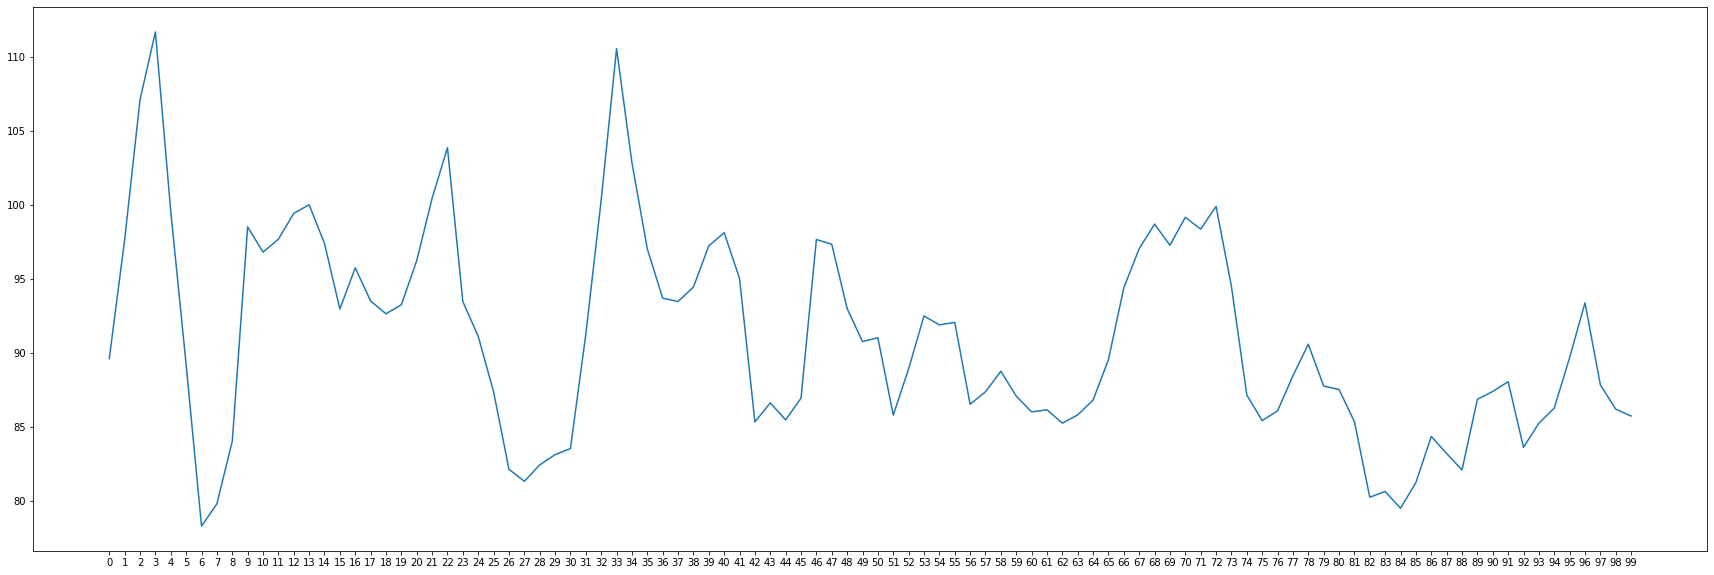

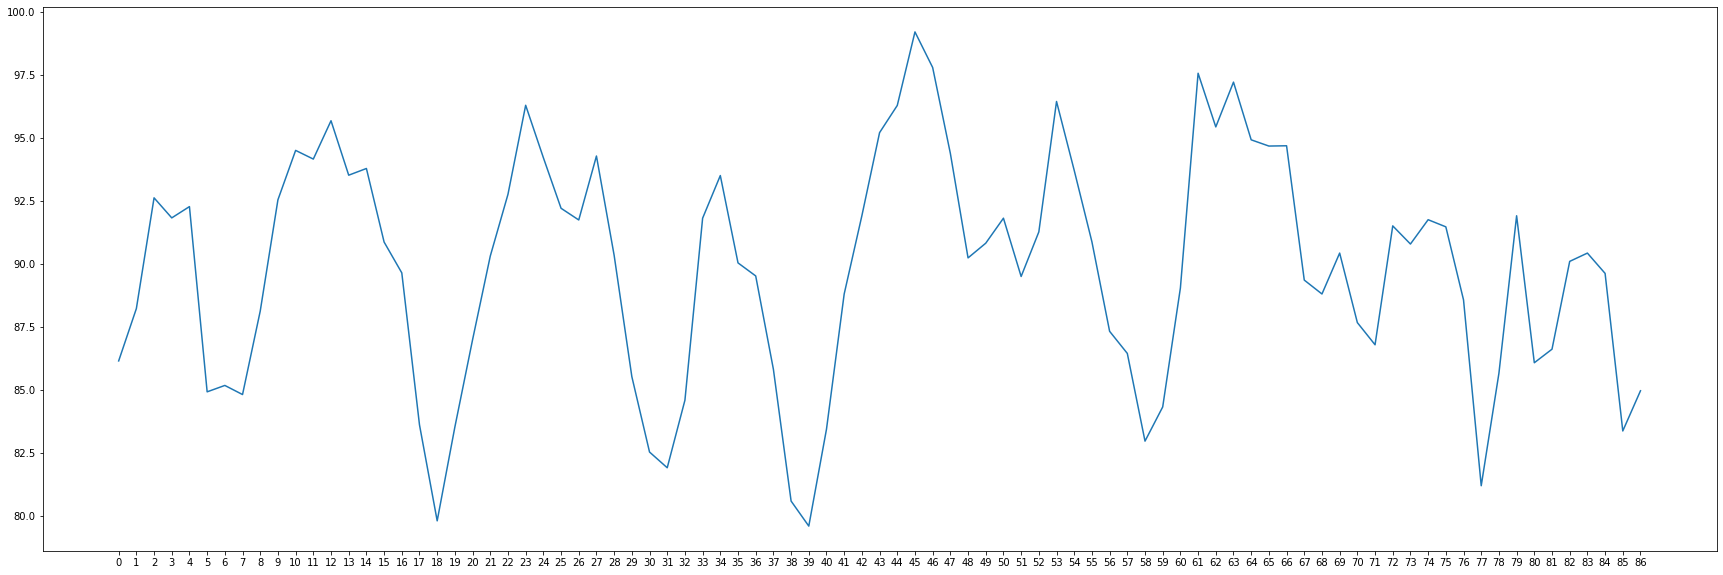

In [59]:
# applying the method to the stabilized video
cap = cv.VideoCapture('stable_video.avi')

# getting the frame rate
fps = cap.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count} ,frames tooked into consideration: {frames_to_take} , values = {frame_count/frames_to_take}")

# applying the method to the video

avg_intensity_frames4, frames4 = applied_method(cap, frames_to_take)

# ploting the average intensity of the average frames
plot_results(avg_intensity_frames4)

index of the biggest difference: 8 , 9


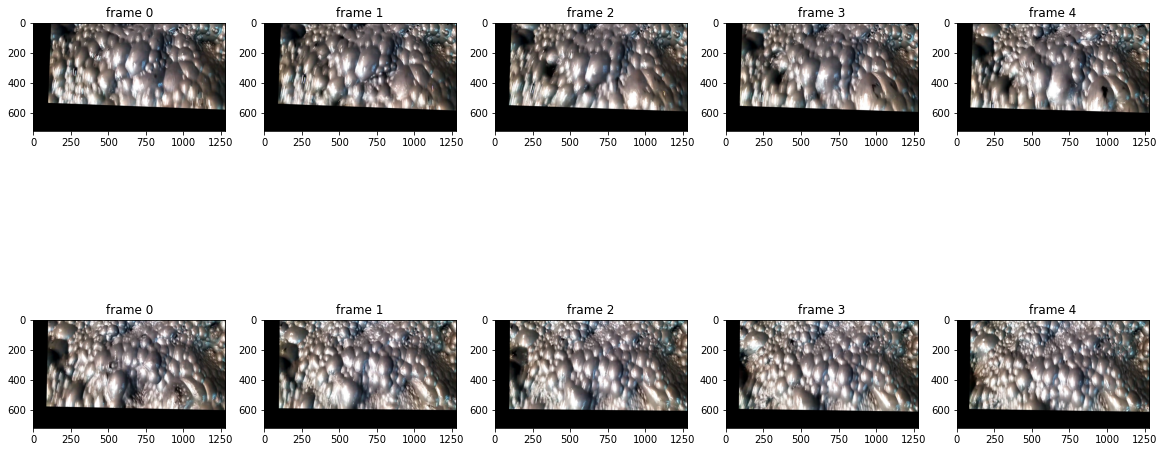

In [60]:
index_of_biggest_difference = get_index_of_biggest_difference(avg_intensity_frames4)

print(f"index of the biggest difference: {index_of_biggest_difference} , {index_of_biggest_difference + 1}")

plot_diff_frames(frames4,index_of_biggest_difference, index_of_biggest_difference + 1)

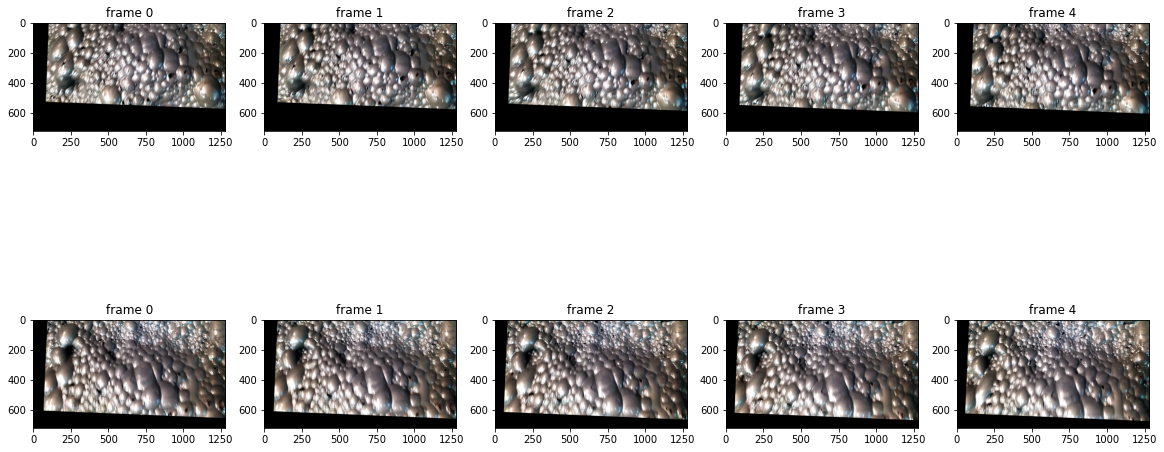

In [62]:
plot_diff_frames(frames4,30, 32)